   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1            5.1           3.5            1.4           0.2  Iris-setosa
1   2            4.9           3.0            1.4           0.2  Iris-setosa
2   3            4.7           3.2            1.3           0.2  Iris-setosa
3   4            4.6           3.1            1.5           0.2  Iris-setosa
4   5            5.0           3.6            1.4           0.2  Iris-setosa

AdaBoost Classifier Results
---------------------------
Accuracy : 0.9333333333333333
Precision: 0.9333333333333333
Recall   : 0.9333333333333333
F1-Score : 0.9333333333333333

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


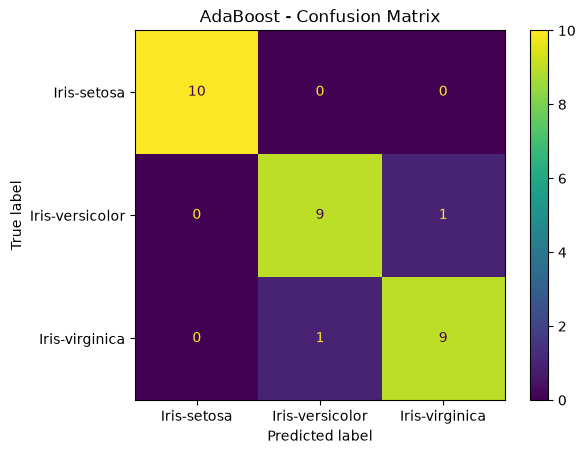

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# Load dataset
df = pd.read_csv("Iris.csv")

# Display dataset
print(df.head())

# Remove Id column
df = df.drop("Id", axis=1)

# Separate features and target
X = df.drop("Species", axis=1)
y = df["Species"]

# Encode target variable
encoder = LabelEncoder()
y = encoder.fit_transform(y)

# Split dataset into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create AdaBoost model
model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation
print("\nAdaBoost Classifier Results")
print("---------------------------")

print("Accuracy :", accuracy_score(y_test, y_pred))

print("Precision:",
      precision_score(y_test, y_pred, average="weighted"))

print("Recall   :",
      recall_score(y_test, y_pred, average="weighted"))

print("F1-Score :",
      f1_score(y_test, y_pred, average="weighted"))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display Confusion Matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot()

plt.title("AdaBoost - Confusion Matrix")
plt.show()